In [26]:
import pandas as pd
import numpy as np

In [27]:
df = pd.read_csv("powerplant_data.csv")

In [28]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [29]:
# AT => temperature
#V => vacume
# AP => pressure
# RH => relative humidity

#PE => produced enerygy

In [30]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [31]:
X = df.drop("PE", axis=1)
y= df["PE"]

y.head()


0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [32]:
# Split out data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
df.shape

(9568, 5)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]])

In [36]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [37]:
type(X_train_scaled)


numpy.ndarray

In [38]:
type(y_train)
y_train.shape

(7654,)

In [39]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [40]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# Deep Learning

In [ ]:

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__() # calling the constructor of the parent class nn.Module

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6, 1),
        )

    def forward(self, x): # forward pass will be called when we call the model on some input data example: model(x)
        return self.model(x)

In [55]:
import torch.optim as optim

model = ANN()

# loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [ ]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad() # zero the gradients of the optimizer before backpropagation
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 205270.20494791667 & val loss = 201924.765625
epoch 2/100 ==> train loss = 189775.0255859375 & val loss = 171199.5625
epoch 3/100 ==> train loss = 143518.37718098957 & val loss = 114239.9453125
epoch 4/100 ==> train loss = 89684.65099283853 & val loss = 70319.9921875
epoch 5/100 ==> train loss = 56641.682397460936 & val loss = 45334.1328125
epoch 6/100 ==> train loss = 34895.017749023435 & val loss = 25847.41015625
epoch 7/100 ==> train loss = 18873.33592529297 & val loss = 13558.4677734375
epoch 8/100 ==> train loss = 10342.603684488933 & val loss = 8130.12060546875
epoch 9/100 ==> train loss = 6596.933067830404 & val loss = 5541.76416015625
epoch 10/100 ==> train loss = 4560.140957132975 & val loss = 3854.304931640625
epoch 11/100 ==> train loss = 3136.672765604655 & val loss = 2667.777587890625
epoch 12/100 ==> train loss = 2167.318909708659 & val loss = 1901.073974609375
epoch 13/100 ==> train loss = 1560.0914998372396 & val loss = 1413.159423828125
epo

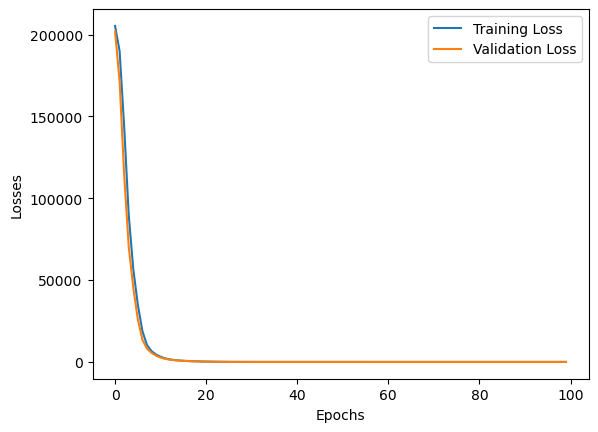

In [57]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [58]:
# loading the best model

model.load_state_dict(torch.load("best_model.pt"))


<All keys matched successfully>

In [59]:
# evaluate our model
from sklearn.metrics import mean_squared_error, r2_score

model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)
    
    train_mse_loss = mean_squared_error(y_train_tensor, train_pred)
    test_mse_loss = mean_squared_error(y_test_tensor, test_pred)
    train_r2 = r2_score(y_train_tensor, train_pred)
    test_r2 = r2_score(y_test_tensor, test_pred)
    
print(f"Train MSE Loss: {train_mse_loss}, Train R2 Score: {train_r2}")
# convert test metrics to tensors so the later .item() calls won't fail

print(f"Test MSE Loss: {test_mse_loss}, Test R2 Score: {test_r2}")


Train MSE Loss: 20.57215341992252, Train R2 Score: 0.9296731322126777
Test MSE Loss: 18.915248510941606, Test R2 Score: 0.933896079173702


In [60]:
predicted_df =pd.DataFrame(
    test_pred.numpy(), columns=["Predicted PE"]
    
)
actual_df = pd.DataFrame(
    y_test_tensor.numpy(), columns=["Actual PE"]
    )

pd.concat([predicted_df, actual_df], axis=1)

,Predicted PE,Actual PE
0,435.304199,433.269989
1,437.009796,438.160004
2,460.946381,458.420013
3,475.913483,480.820007
4,435.024994,441.410004
...,...,...
1909,451.452484,456.700012
1910,431.718262,438.040009
1911,467.431030,467.799988
1912,431.122345,437.140015


In [61]:
# lets compare it with linear regression model

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

linear_pred_df = pd.DataFrame(y_pred, columns=["Linear Regression Predictions"])
linear_pred_df = pd.concat([linear_pred_df, actual_df], axis=1)

linear_pred_df

print(f"Linear Regression MSE Loss: {mean_squared_error(y_test, y_pred)}, R2 Score: {r2_score(y_test, y_pred)}")

Linear Regression MSE Loss: 19.60808532568379, R2 Score: 0.9314747936670362


In [62]:
#let's compare the performance of our ANN model with the Linear Regression model. The ANN model achieved a lower MSE loss and a higher R2 score compared to the Linear Regression model, indicating that the ANN model is better at capturing the underlying patterns in the data.

In [64]:
# compare with  svr

from sklearn.svm import SVR

model = SVR()
model.fit(X_train_scaled, y_train)
y_pred_svr = model.predict(X_test_scaled)

print(f"SVR MSE Loss: {mean_squared_error(y_test, y_pred_svr)}, R2 Score: {r2_score(y_test, y_pred_svr)}")

svr_pred_df = pd.DataFrame(y_pred_svr, columns=["SVR Predictions"])
svr_pred_df = pd.concat([svr_pred_df, actual_df], axis=1)
svr_pred_df

SVR MSE Loss: 16.237382072654366, R2 Score: 0.943254533099243


,SVR Predictions,Actual PE
0,434.825792,433.269989
1,435.655919,438.160004
2,459.195318,458.420013
3,477.591204,480.820007
4,438.283633,441.410004
...,...,...
1909,450.011424,456.700012
1910,433.567660,438.040009
1911,468.186329,467.799988
1912,433.146843,437.140015


In [65]:
# decision tree regressor
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42, max_depth=5)

model.fit(X_train, y_train)

y_pred_dt = model.predict(X_test)

print(f"Decision Tree Regressor MSE Loss: {mean_squared_error(y_test, y_pred_dt)}, R2 Score: {r2_score(y_test, y_pred_dt)}")

dt_pred_df = pd.DataFrame(y_pred_dt, columns=["Decision Tree Predictions"])
dt_pred_df = pd.concat([dt_pred_df, actual_df], axis=1)

dt_pred_df

Decision Tree Regressor MSE Loss: 18.57093394823826, R2 Score: 0.9350993705167135


,Decision Tree Predictions,Actual PE
0,436.692885,433.269989
1,435.522287,438.160004
2,460.827176,458.420013
3,477.919716,480.820007
4,441.035186,441.410004
...,...,...
1909,448.316197,456.700012
1910,432.144770,438.040009
1911,466.211004,467.799988
1912,432.144770,437.140015
